In [2]:
from ultralytics import YOLO
import os

In [3]:
model = YOLO(os.path.join("runs","detect","train-3","weights","best.pt"))

In [4]:
images_val = os.path.join("training_data","images","val")
labels_val = os.path.join("training_data","labels","val")
os.listdir(images_val)

['031fe115-BikesHelmets377.png',
 '03e914b1-BikesHelmets398.png',
 '04346efe-BikesHelmets419.png',
 '047c959e-BikesHelmets544.png',
 '04f801dd-BikesHelmets77.png',
 '072213d4-BikesHelmets379.png',
 '07550fbd-BikesHelmets384.png',
 '08e44d1d-BikesHelmets85.png',
 '08ec3c0f-BikesHelmets126.png',
 '09f1bf43-BikesHelmets404.png',
 '0a4fbd76-BikesHelmets74.png',
 '0d78636b-BikesHelmets406.png',
 '0df87d43-BikesHelmets471.png',
 '0fdf502b-BikesHelmets386.png',
 '105e0c65-BikesHelmets81.png',
 '10e3303c-BikesHelmets463.png',
 '11ba64a1-BikesHelmets545.png',
 '15cbba0d-BikesHelmets490.png',
 '16727be4-BikesHelmets122.png',
 '16e84192-BikesHelmets312.png',
 '17e7f9e3-BikesHelmets539.png',
 '196d285f-BikesHelmets717.png',
 '19ea0767-BikesHelmets427.png',
 '1b8e8f6b-BikesHelmets321.png',
 '1b918921-BikesHelmets372.png',
 '1d5c2b6c-BikesHelmets414.png',
 '1dd2e24b-BikesHelmets365.png',
 '1e61430e-BikesHelmets479.png',
 '1f82a27b-BikesHelmets428.png',
 '1f94c1bf-BikesHelmets45.png',
 '25ee9ea4-Bike

In [5]:
os.listdir(labels_val)

['031fe115-BikesHelmets377.txt',
 '03e914b1-BikesHelmets398.txt',
 '04346efe-BikesHelmets419.txt',
 '047c959e-BikesHelmets544.txt',
 '04f801dd-BikesHelmets77.txt',
 '072213d4-BikesHelmets379.txt',
 '07550fbd-BikesHelmets384.txt',
 '08e44d1d-BikesHelmets85.txt',
 '08ec3c0f-BikesHelmets126.txt',
 '09f1bf43-BikesHelmets404.txt',
 '0a4fbd76-BikesHelmets74.txt',
 '0d78636b-BikesHelmets406.txt',
 '0df87d43-BikesHelmets471.txt',
 '0fdf502b-BikesHelmets386.txt',
 '105e0c65-BikesHelmets81.txt',
 '10e3303c-BikesHelmets463.txt',
 '11ba64a1-BikesHelmets545.txt',
 '15cbba0d-BikesHelmets490.txt',
 '16727be4-BikesHelmets122.txt',
 '16e84192-BikesHelmets312.txt',
 '17e7f9e3-BikesHelmets539.txt',
 '196d285f-BikesHelmets717.txt',
 '19ea0767-BikesHelmets427.txt',
 '1b8e8f6b-BikesHelmets321.txt',
 '1b918921-BikesHelmets372.txt',
 '1d5c2b6c-BikesHelmets414.txt',
 '1dd2e24b-BikesHelmets365.txt',
 '1e61430e-BikesHelmets479.txt',
 '1f82a27b-BikesHelmets428.txt',
 '1f94c1bf-BikesHelmets45.txt',
 '25ee9ea4-Bike

With Helmet


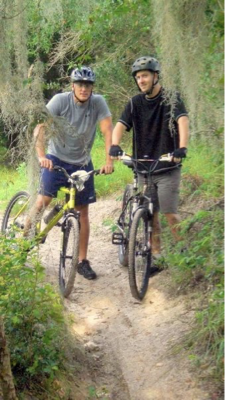

In [6]:
sample = "105e0c65-BikesHelmets81"

class_labels = ["With Helmet", "Without Helmet"]
with open(os.path.join(labels_val, sample+'.txt')) as f:
    int_cls = int(f.read().split(" ")[0])
    print(class_labels[int_cls])

from IPython.display import Image, display
display(Image(filename = os.path.join(images_val, sample+'.png')))

In [7]:
model = YOLO(os.path.join("runs","detect","train-3","weights","best.pt"))

In [8]:
img_path = os.path.join(images_val, sample+'.png')
y_pred = model.predict(img_path, conf = 0.4)



image 1/1 c:\venv created copy 2 class perfect model\training_data\images\val\105e0c65-BikesHelmets81.png: 640x384 2 With Helmets, 72.6ms
Speed: 1.8ms preprocess, 72.6ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 384)


In [9]:
for result in y_pred:
    if not result.boxes:
        print("No predictions")
        continue

    for box in result.boxes:
        cls_id = int(box.cls[0].item())
        detected = result.names[cls_id]

        confidence = box.conf[0].item()

        xmin, ymin, xmax, ymax = box.xyxy[0].tolist()

        print(f"Detected: {detected} | confidence: {confidence:.2f} | Box co-ords: {xmin:.2f}, {ymin:.2f}, {xmax:.2f}, {ymax:.2f}")

Detected: With Helmet | confidence: 0.88 | Box co-ords: 130.55, 55.26, 163.42, 99.24
Detected: With Helmet | confidence: 0.72 | Box co-ords: 66.78, 65.23, 99.05, 105.03


In [10]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [19]:
import cv2


# Load trained model
# Use the relative path to where the file is actually located
model = YOLO("runs/detect/train-3/weights/best.pt")  # Replace with your model path

# Open webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

while True:
    success, frame = cap.read()

    if not success:
        print("Error: Could not read frame.")
        break

    # Run inference
    results = model.predict(frame, conf=0.4)

    for result in results:
        if len(result.boxes) == 0:
            continue

        for box in result.boxes:
            # Get class information
            cls_id = int(box.cls[0].item())
            detected = result.names[cls_id]
            confidence = box.conf[0].item()

            # Get bounding box coordinates
            xmin, ymin, xmax, ymax = map(int, box.xyxy[0].tolist())

            # Set color based on class
            if detected == "With Helmet":
                color = (0, 255, 0)      # Green
            elif detected == "Without Helmet":
                color = (0, 0, 255)      # Red
            else:
                color = (255, 255, 255)  # White (fallback)

            # Draw bounding box
            cv2.rectangle(frame, (xmin, ymin), (xmax, ymax), color, 2)

            # Draw label
            label = f"{detected} {confidence:.2f}"
            cv2.putText(
                frame,
                label,
                (xmin, ymin - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2
            )

    # Display output
    cv2.imshow("Helmet Detection", frame)

    # Press Q to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()


0: 480x640 (no detections), 104.3ms
Speed: 2.5ms preprocess, 104.3ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 102.7ms
Speed: 2.4ms preprocess, 102.7ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 80.6ms
Speed: 1.7ms preprocess, 80.6ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 78.8ms
Speed: 1.4ms preprocess, 78.8ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 75.0ms
Speed: 2.7ms preprocess, 75.0ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 78.6ms
Speed: 2.2ms preprocess, 78.6ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 82.6ms
Speed: 2.3ms preprocess, 82.6ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 84.4ms
Speed: 2.3ms preprocess, 84.4